In [2]:
# 07_loyalty_hierarchical.ipynb

# 1. DATA LOADING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load preprocessed dataset
df = pd.read_csv("preprocessed_customer_data.csv")

In [3]:
# 2. FEATURE SELECTION (LOYALTY & ENGAGEMENT)

loyalty_features = [
    'Customer_Tenure', 'Recency', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]
X = df[loyalty_features]

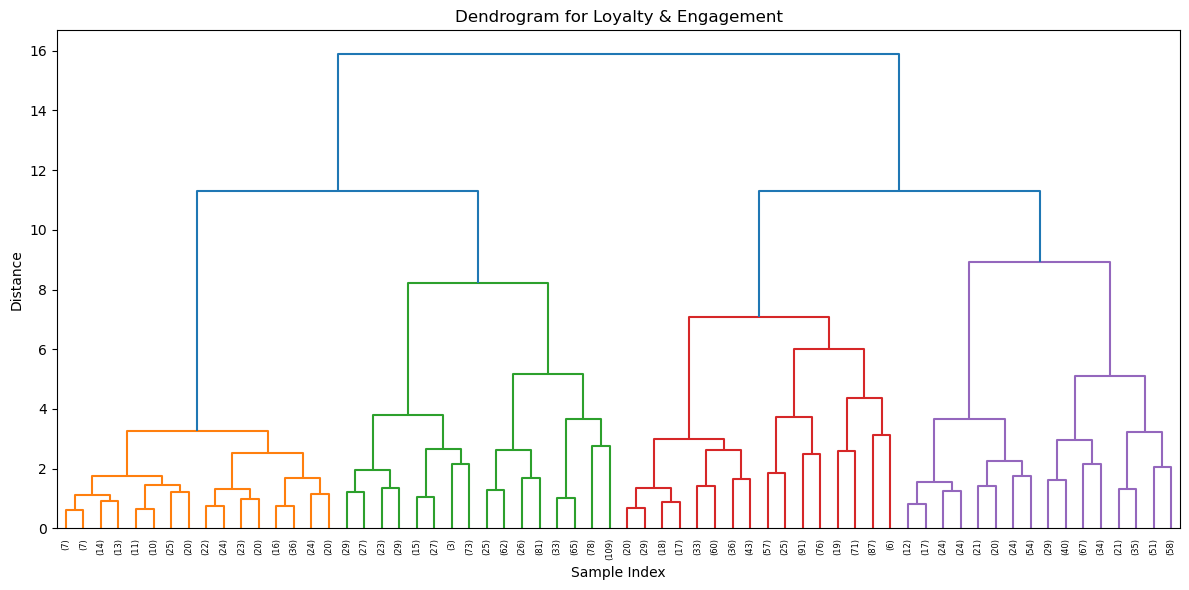

In [4]:
# 3. DENDROGRAM TO DETERMINE CLUSTER NUMBER

linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Dendrogram for Loyalty & Engagement")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [8]:
# 4. APPLY AGNES CLUSTERING

optimal_k = 4  # Select based on dendrogram
agnes = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['LoyaltyCluster_AGNES'] = agnes.fit_predict(X)

# Evaluate quality of clustering
score = silhouette_score(X, df['LoyaltyCluster_AGNES'])
print(f"Silhouette Score (AGNES, k={optimal_k}): {score:.4f}")

Silhouette Score (AGNES, k=4): 0.1674



📊 Loyalty & Engagement Cluster Profiles:


,Customer_Tenure,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
LoyaltyCluster_AGNES,,,,,,,
0,0.663428,0.518290,0.159448,0.214201,0.164380,0.747356,0.213748
1,0.272422,0.277914,0.122270,0.126294,0.074873,0.393890,0.250000
2,0.730716,0.559020,0.205136,0.148202,0.075685,0.325134,0.334738
3,0.252322,0.826519,0.107078,0.104642,0.065925,0.310327,0.237329


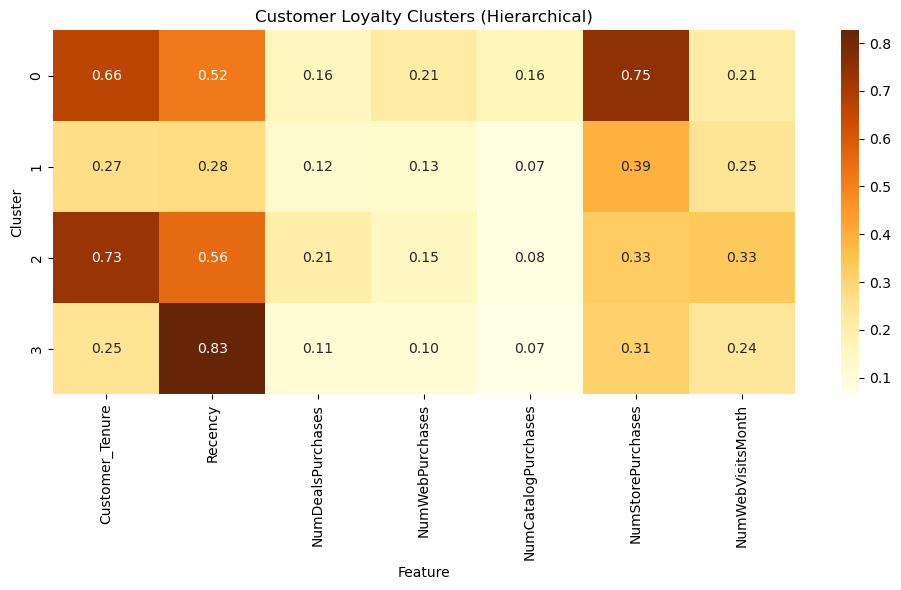

In [10]:
# 5. CLUSTER PROFILE ANALYSIS

cluster_profile = df.groupby('LoyaltyCluster_AGNES')[loyalty_features].mean()
print("\n📊 Loyalty & Engagement Cluster Profiles:")
display(cluster_profile)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Customer Loyalty Clusters (Hierarchical)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

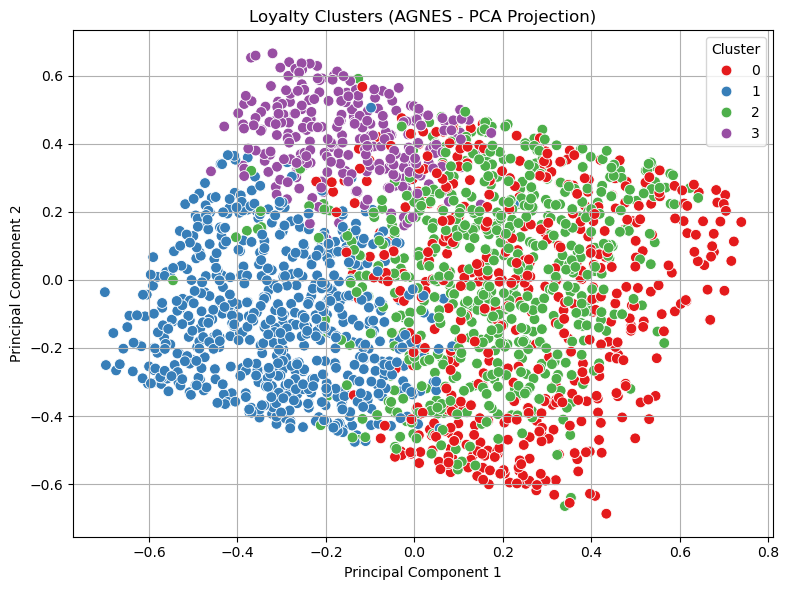

In [12]:
# 6. VISUALIZE CLUSTERS USING PCA (2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['LoyaltyCluster_AGNES']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=60)
plt.title("Loyalty Clusters (AGNES - PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()